<a href="https://colab.research.google.com/github/arjunnp20-design/first/blob/main/Bike_rental_DS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PRCP-1018-BikeRental**

#**Project team's ID : PTID-CDS-MAY-26-11231**

**Task 1 :** Prepare a complete data analysis report on the given data.

**Task 2 :** prediction of daily bike rental count based on the environmental and seasonal settings.

**Dataset informatrion**

This dataset contains the daily count of rental bikes between years 2011 and 2012 in the capital bike shares system with the corresponding weather and seasonal information.Bike sharing systems are a new version of tradional bike rentals where the whole process from membership, rental and return back at another postion.currently, there are about over 500 bike -sharing programs around the world which is composed of over 500 thousands bicycles.Today,there exists great interest in these systems due to their important role in traffic,enivrionment and health issues.Apart from interesting real world applications of bike sharing systems,the characterstics of data being generated by these systems makes them attractive for research. Opposed to other transport servicees such as bus or subways,the duration of travels,departure and arrival position is expicitly recorded in these systems. this feature turns the bike sharing system into virtual sensor network that can be used for sensing mobility in the city.Hence,it is expected that most of the important events in the city could be detected via monitoring these data.

____________________________________________________



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
data = pd.read_csv('day.csv')

In [ ]:
data

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,727,2012-12-27,1,1,12,0,4,1,2,0.254167,0.226642,0.652917,0.350133,247,1867,2114
727,728,2012-12-28,1,1,12,0,5,1,2,0.253333,0.255046,0.590000,0.155471,644,2451,3095
728,729,2012-12-29,1,1,12,0,6,0,2,0.253333,0.242400,0.752917,0.124383,159,1182,1341
729,730,2012-12-30,1,1,12,0,0,0,1,0.255833,0.231700,0.483333,0.350754,364,1432,1796


In [ ]:
data.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


**Observation : No null values and every function are in numerical there is no categorical data.**

In [ ]:
data["season"].unique()

array([1, 2, 3, 4])

In [ ]:
data["weekday"].unique()

array([6, 0, 1, 2, 3, 4, 5])

In [ ]:
data["workingday"].unique()

array([0, 1])

In [ ]:
data["weathersit"].value_counts()

,count
weathersit,
1,463
2,247
3,21


In [ ]:
data.shape

(731, 16)

In [ ]:
data.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [ ]:
data.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [ ]:
data.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64
temp,float64


In [ ]:
data = data.drop('instant',axis = 1)

#**Observations**
*   Total no of days = 731
*   Number of rows and columns = 731 x16
*   the average number of rentals per hour is 4504.35,with a standard deviation of 1937.21
*   min.number of rentals (in a hour) = 22
*   max.number of rentals (in a hour) = 8714
*   the average temperature ~ 0.5 ,with a standard deviation of 0.18

*   the average humidity ~ 0.63 ,with a standard deviation of 0.14
*   the average wind speed ~ 0.19 , with standard deviation of 0.08
*   dteday is object type data all other data is numerical
*  droped the instant column because of its irrevalance

___________________________________











##***EDA***

In [ ]:

!pip install sweetviz
import sweetviz as sv
my_report = sv.analyze(data)
my_report.show_html()

                                             |          | [  0%]   00:00 -> (? left)

Report SWEETVIZ_REPORT.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


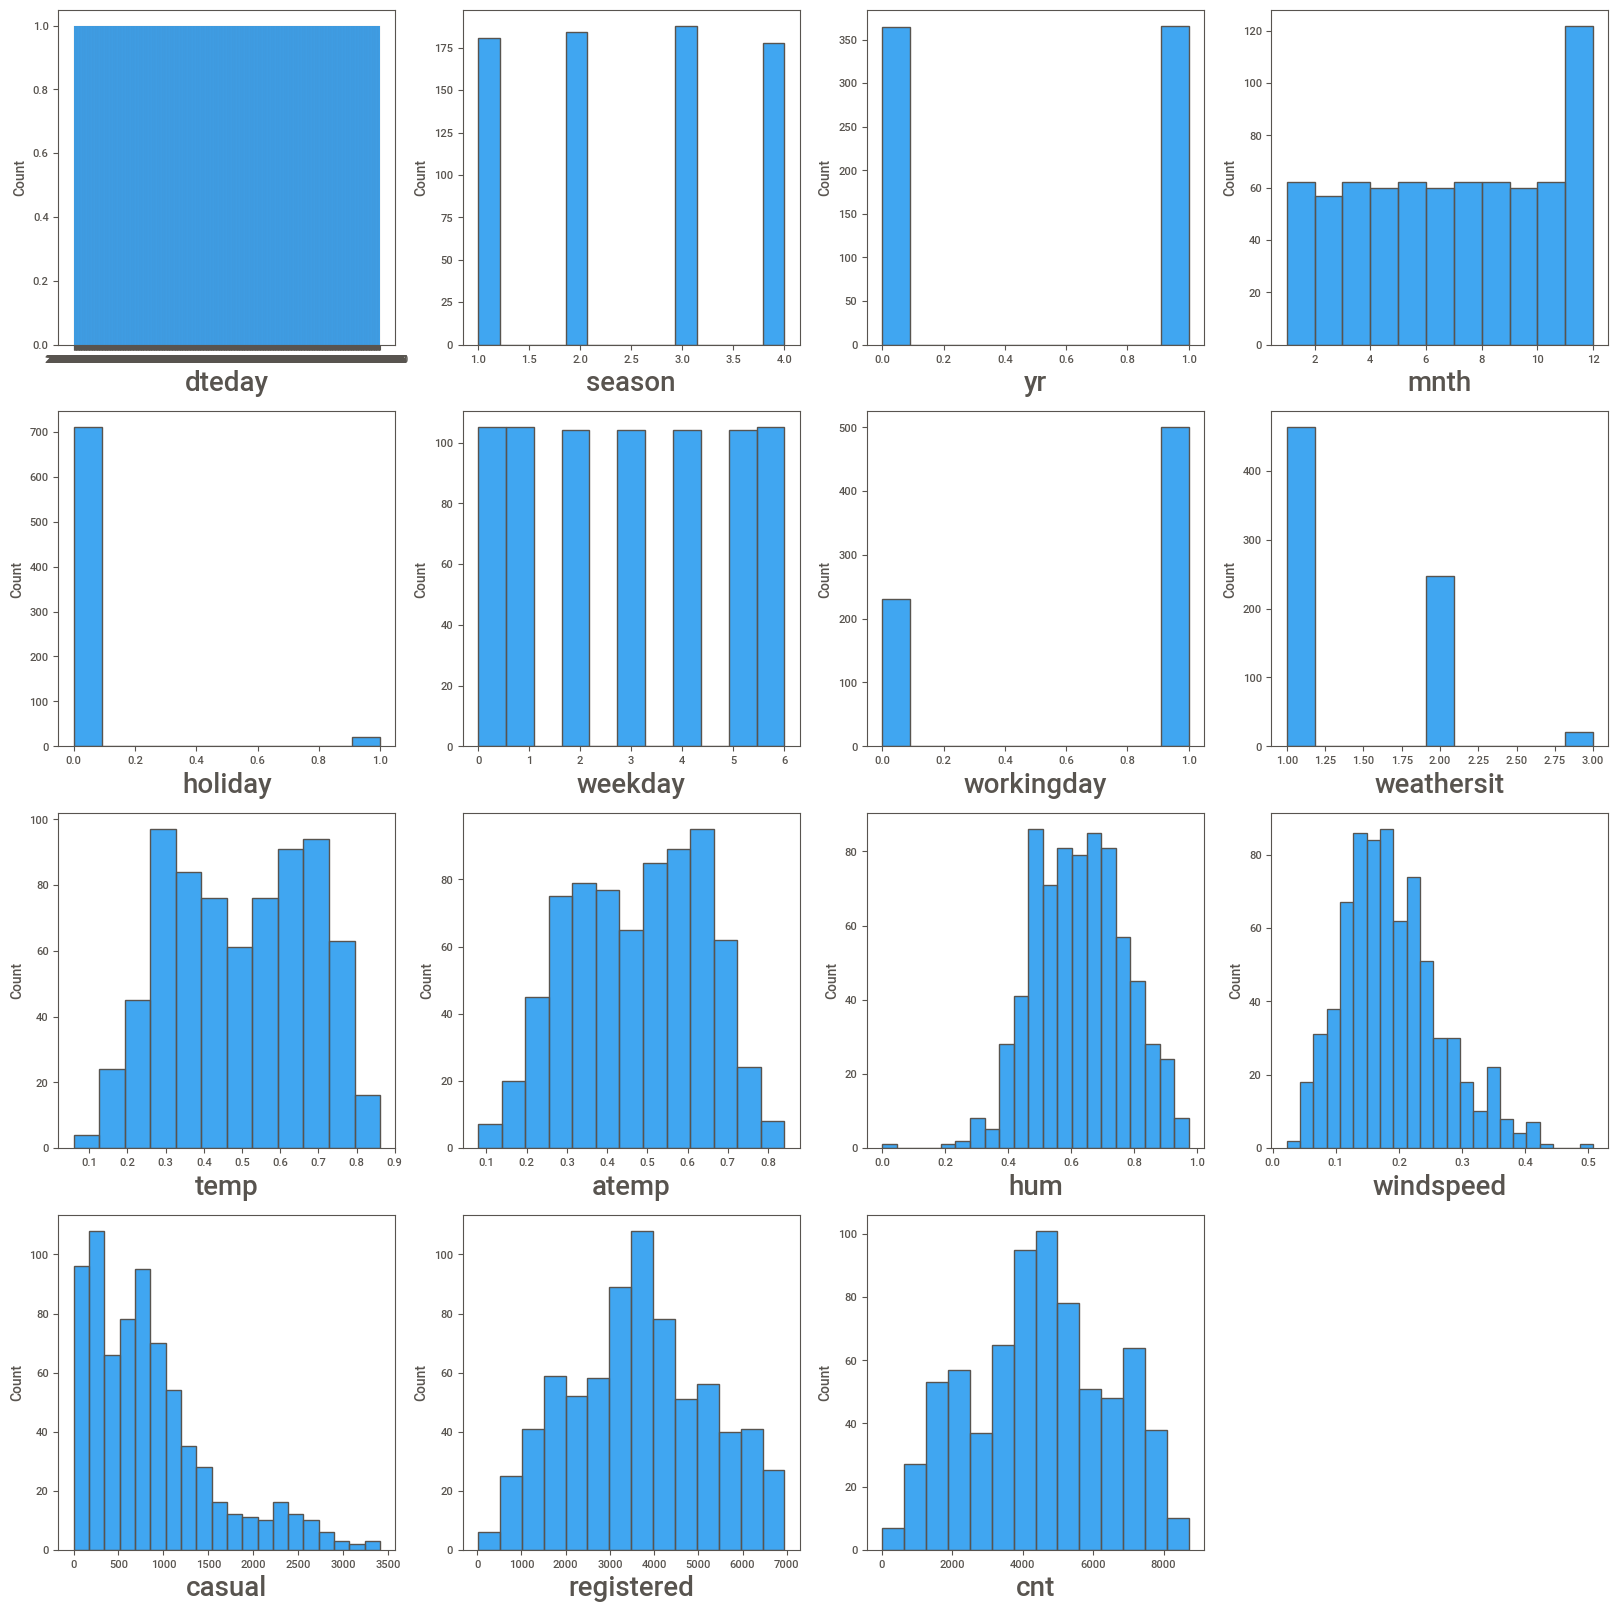

In [ ]:
plt.figure(figsize=(20,20))
plotnummber = 1
for column in data.columns:
  if plotnummber <= 16:
    ax = plt.subplot(4,4,plotnummber)
    sns.histplot(data[column])
    plt.xlabel(column,fontsize = 20)
  plotnummber += 1
plt.show()

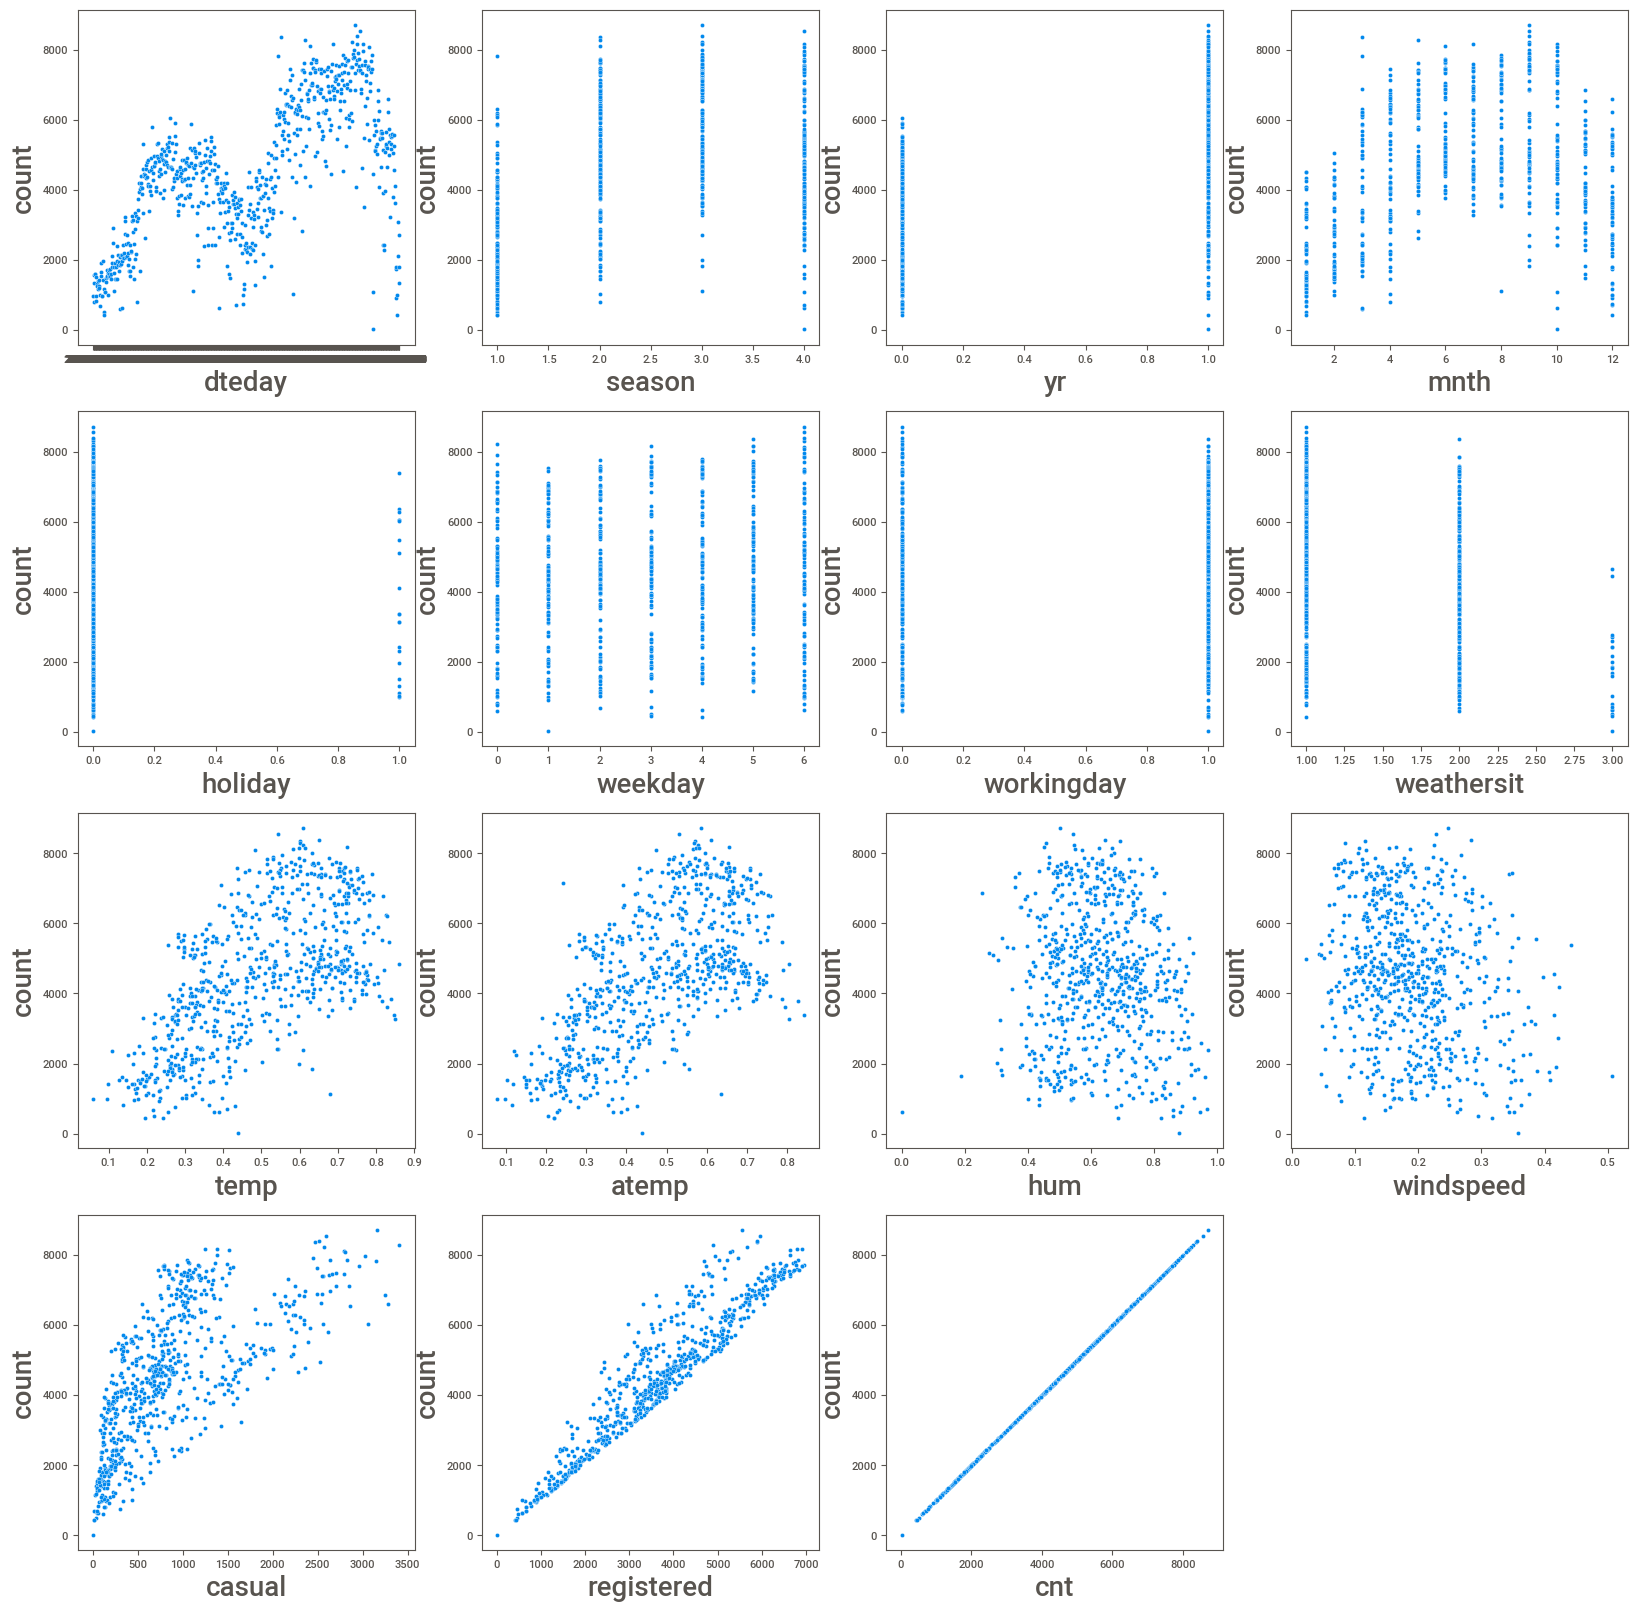

In [ ]:
plt.figure(figsize=(20,20))
plotnumber = 1
for column in data.columns:
    ax = plt.subplot(4,4,plotnumber)
    sns.scatterplot(data = data, x=column,y="cnt")
    plt.xlabel(column,fontsize = 20)
    plt.ylabel("count",fontsize = 20)
    plotnumber += 1
plt.show()

#**Observations**


*   there are no much change of frequencies of season,year and weekday
*   the last month have high count compared with all other months
*   the count is high on holidays
*   the count is high on workingdays compared to non working days
*   the count increased as the temp got warmer and goes to the lowest when temp is at the highest
*   the count is low at low humidty and increases as the humidity increases
*   when there is too much wind bike rental is too low
*   registered bike rental is higher than casual rentals.

#**Conclusion**
*    there is a linear relation between bike rental count and temperature,as warmer the temp is the more bike gets rented.
*    Temp and atemp have similar distribution and may present redunacy and even multicollinerarity.Hence, we can drop out atemp.
*    the bike rental is lowest at low humidity and gets increasredas the humidity increases when there is muvh wind bike rental ls too low.


_____________________________________



#**Data Preprocessing and Feature Engineering**

Removing of unwanted and redundant features:
*    dteday
*    casual
*    registered

In [ ]:
data = data.drop(['dteday','casual','registered'],axis= 1)

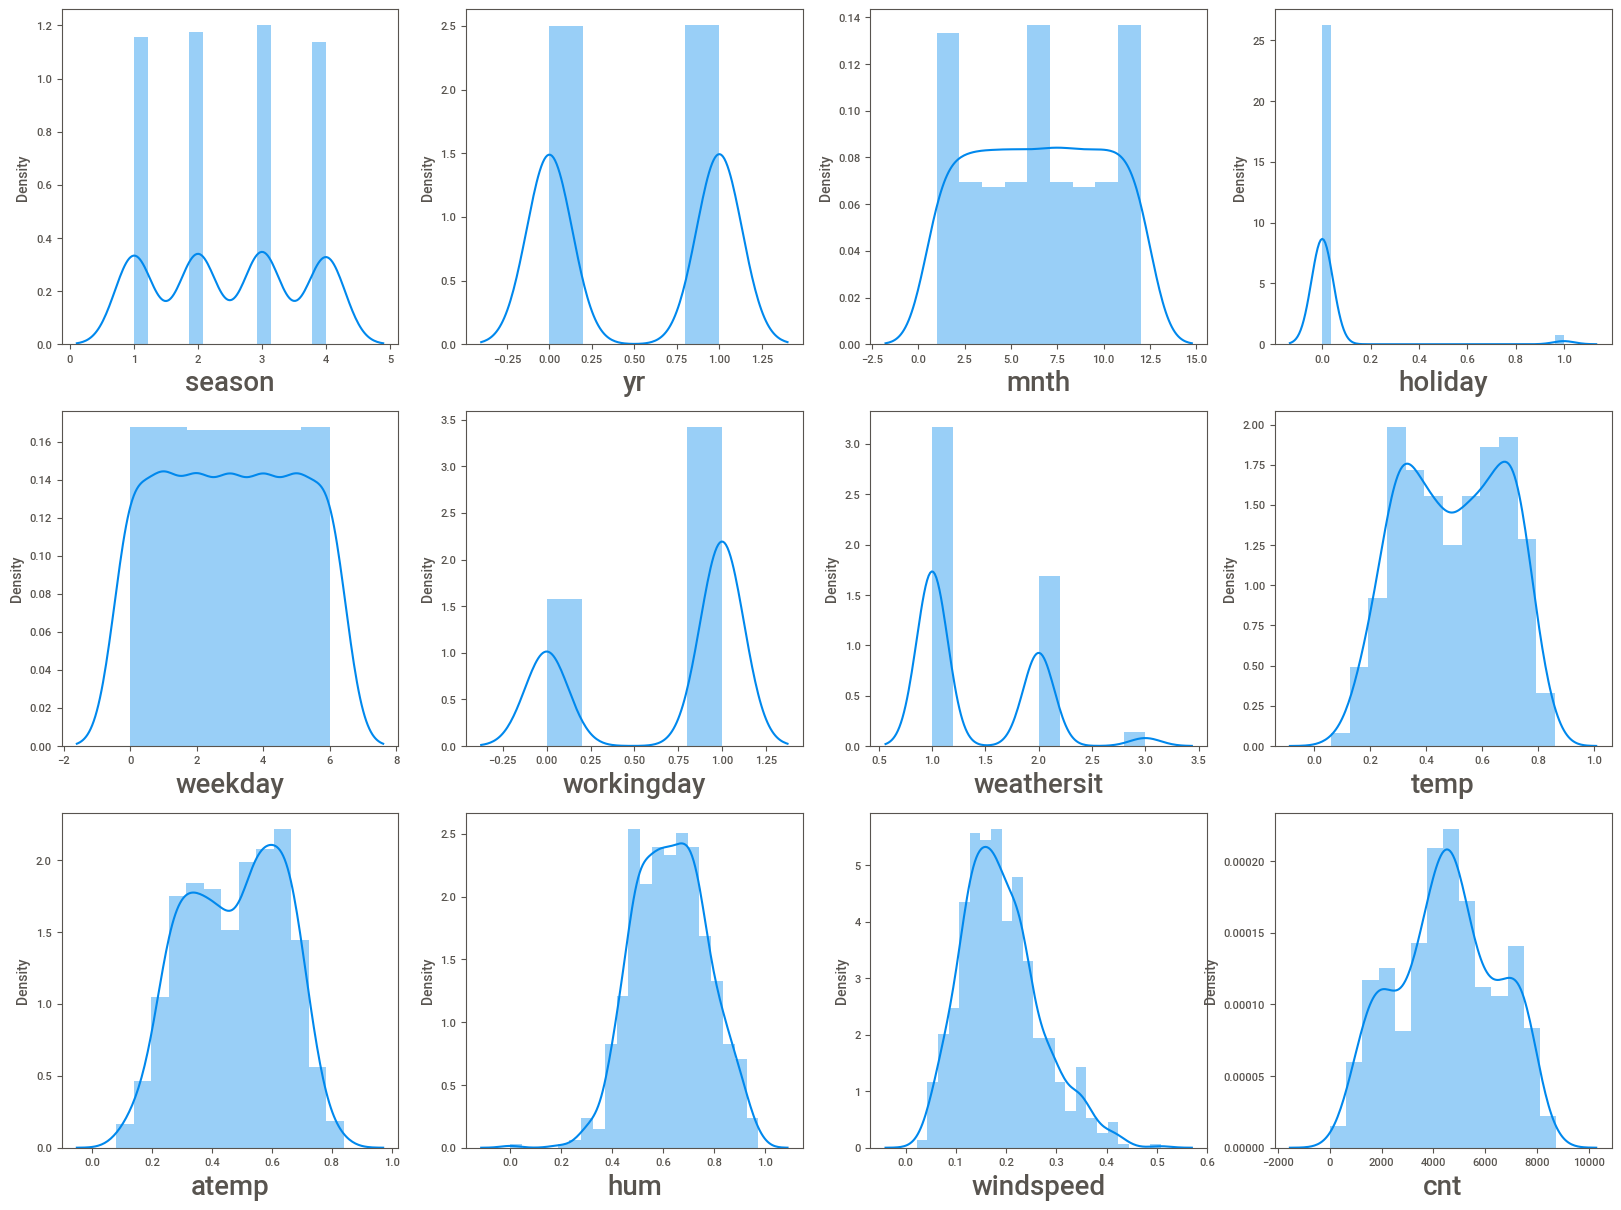

In [ ]:
plt.figure(figsize=(20,20))
plotnumber = 1
for column in data.columns:
    ax = plt.subplot(4,4,plotnumber)
    sns.distplot(data[column])
    plt.xlabel(column,fontsize = 20)
    plotnumber += 1
plt.show()

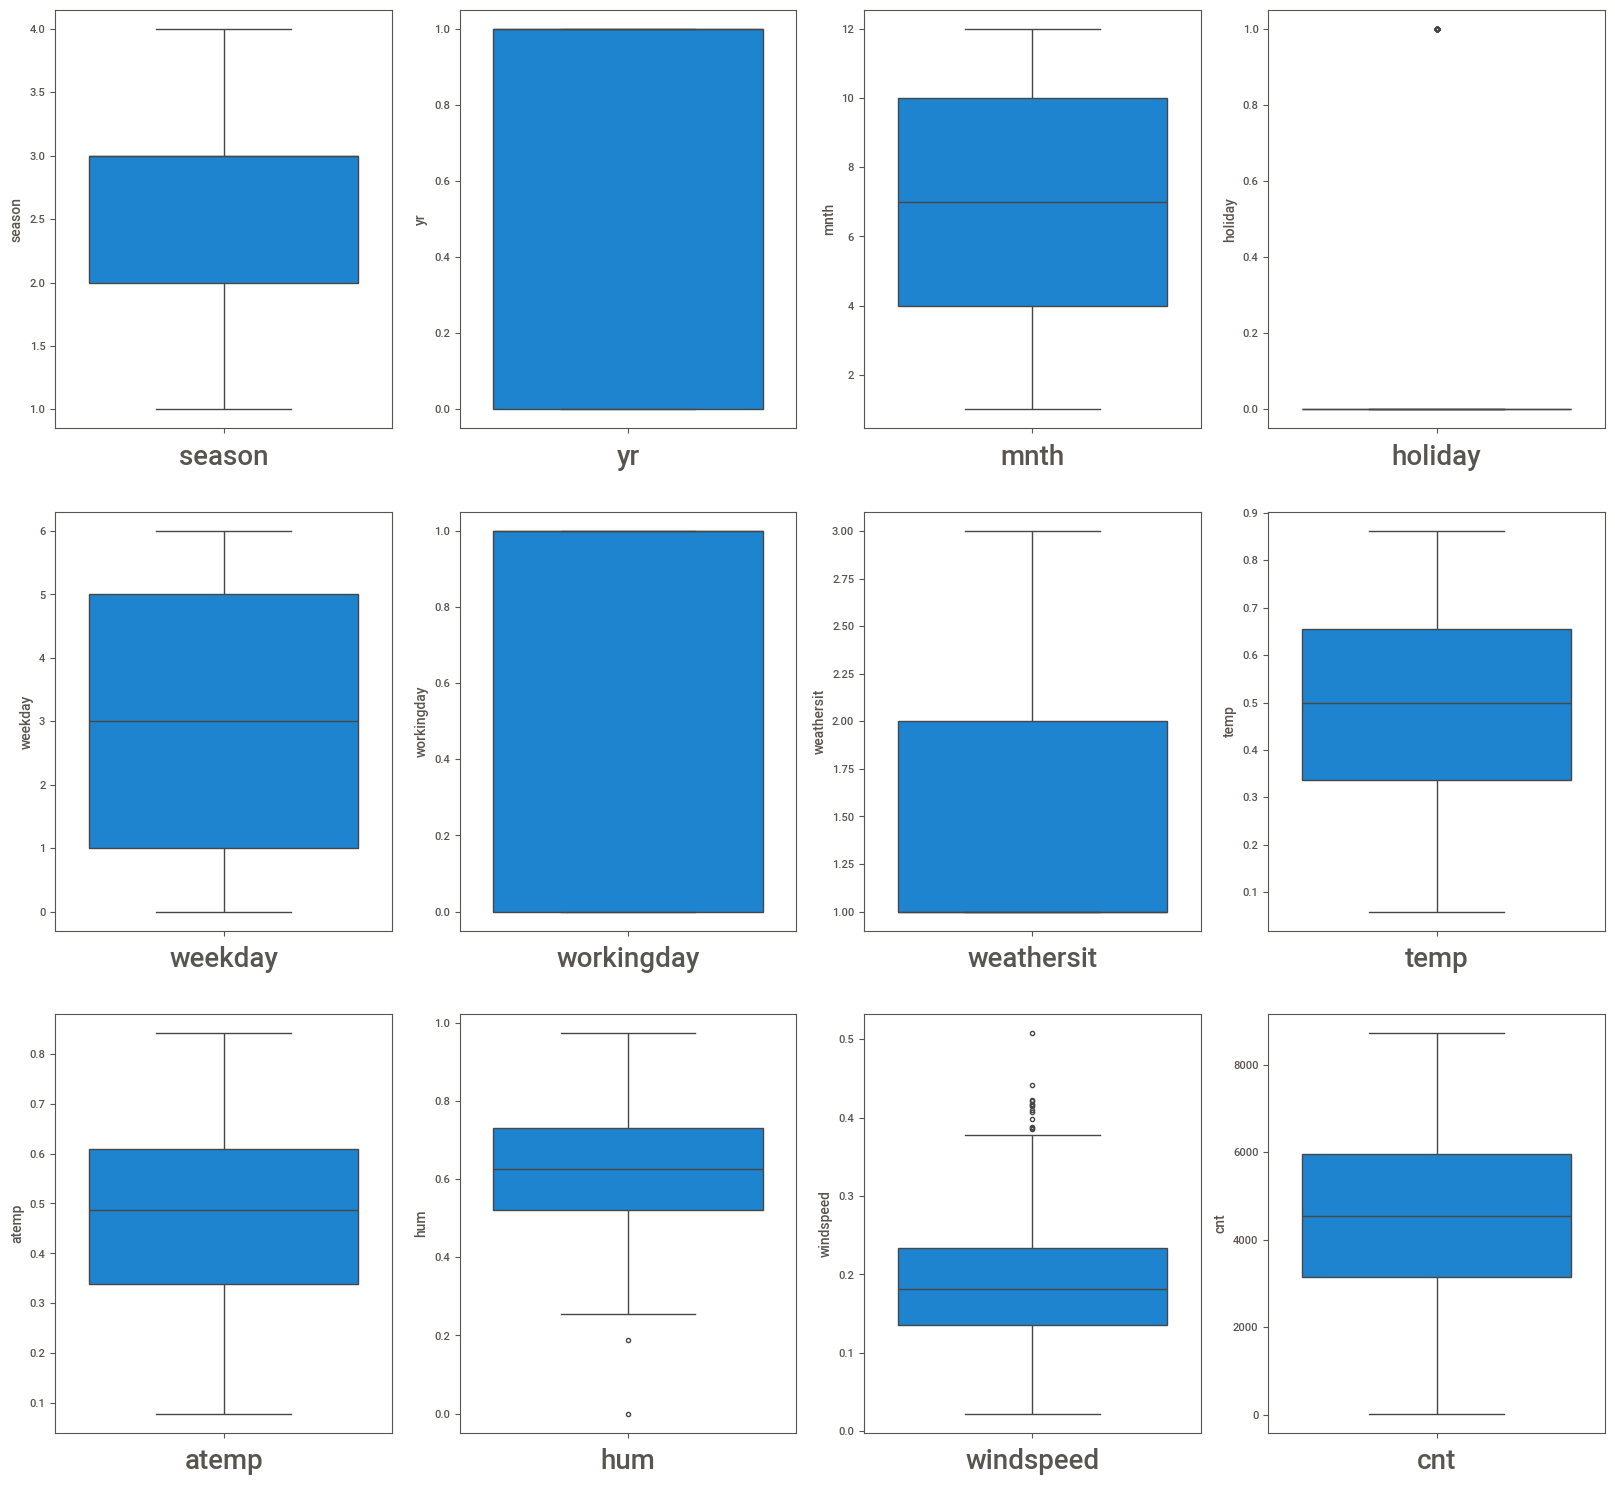

In [ ]:
plt.figure(figsize=(20,25))
plotnumber = 1
for column in data.columns:
  if plotnumber <= 16:
    ax = plt.subplot(4,4,plotnumber)
    sns.boxplot(data[column])
    plt.xlabel(column,fontsize = 20)
  plotnumber += 1
plt.show()

**Observations and conclusions**

*   due to no skewness in the features there is a need for imputation.
*   the box plot shows that there are no extreme values or any unusal values.
*   the box plot also shows that there are no outliners present.

___


**Feature selection**

<Axes: >

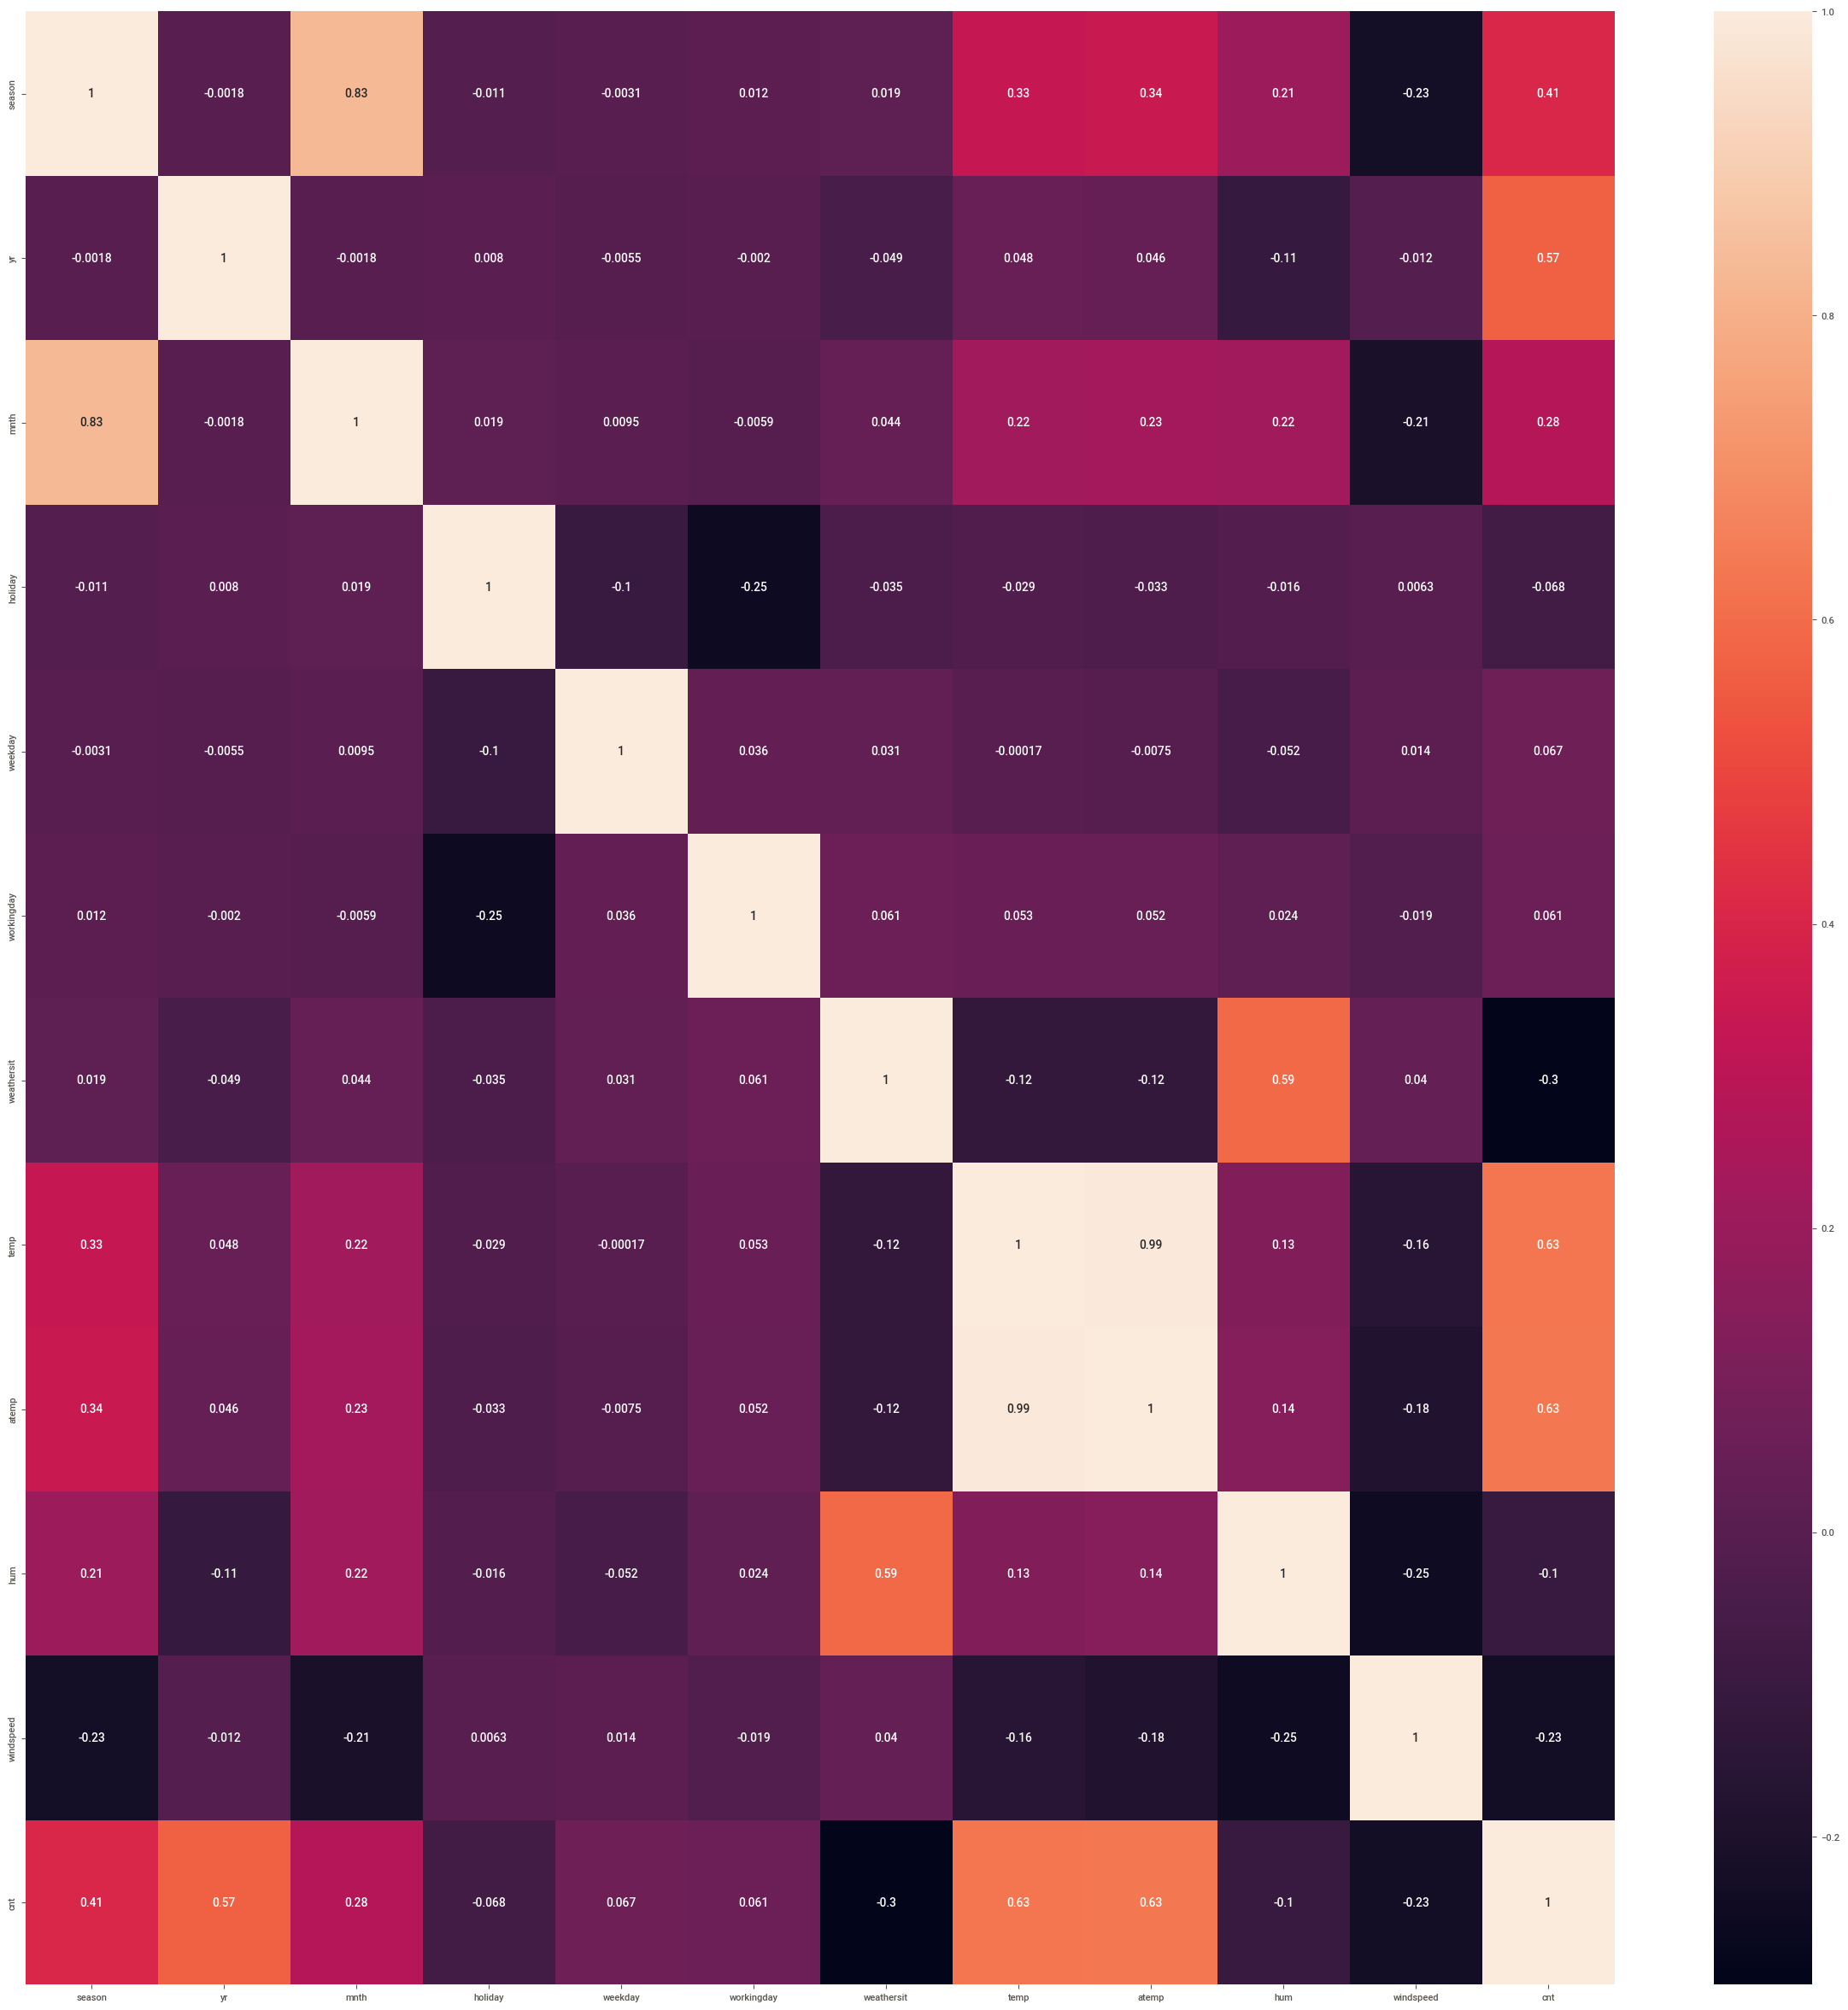

In [ ]:
plt.figure(figsize = (30,30))
sns.heatmap(data.corr(),annot = True)

In [ ]:
data = data.drop(['atemp'],axis = 1)

<Axes: >

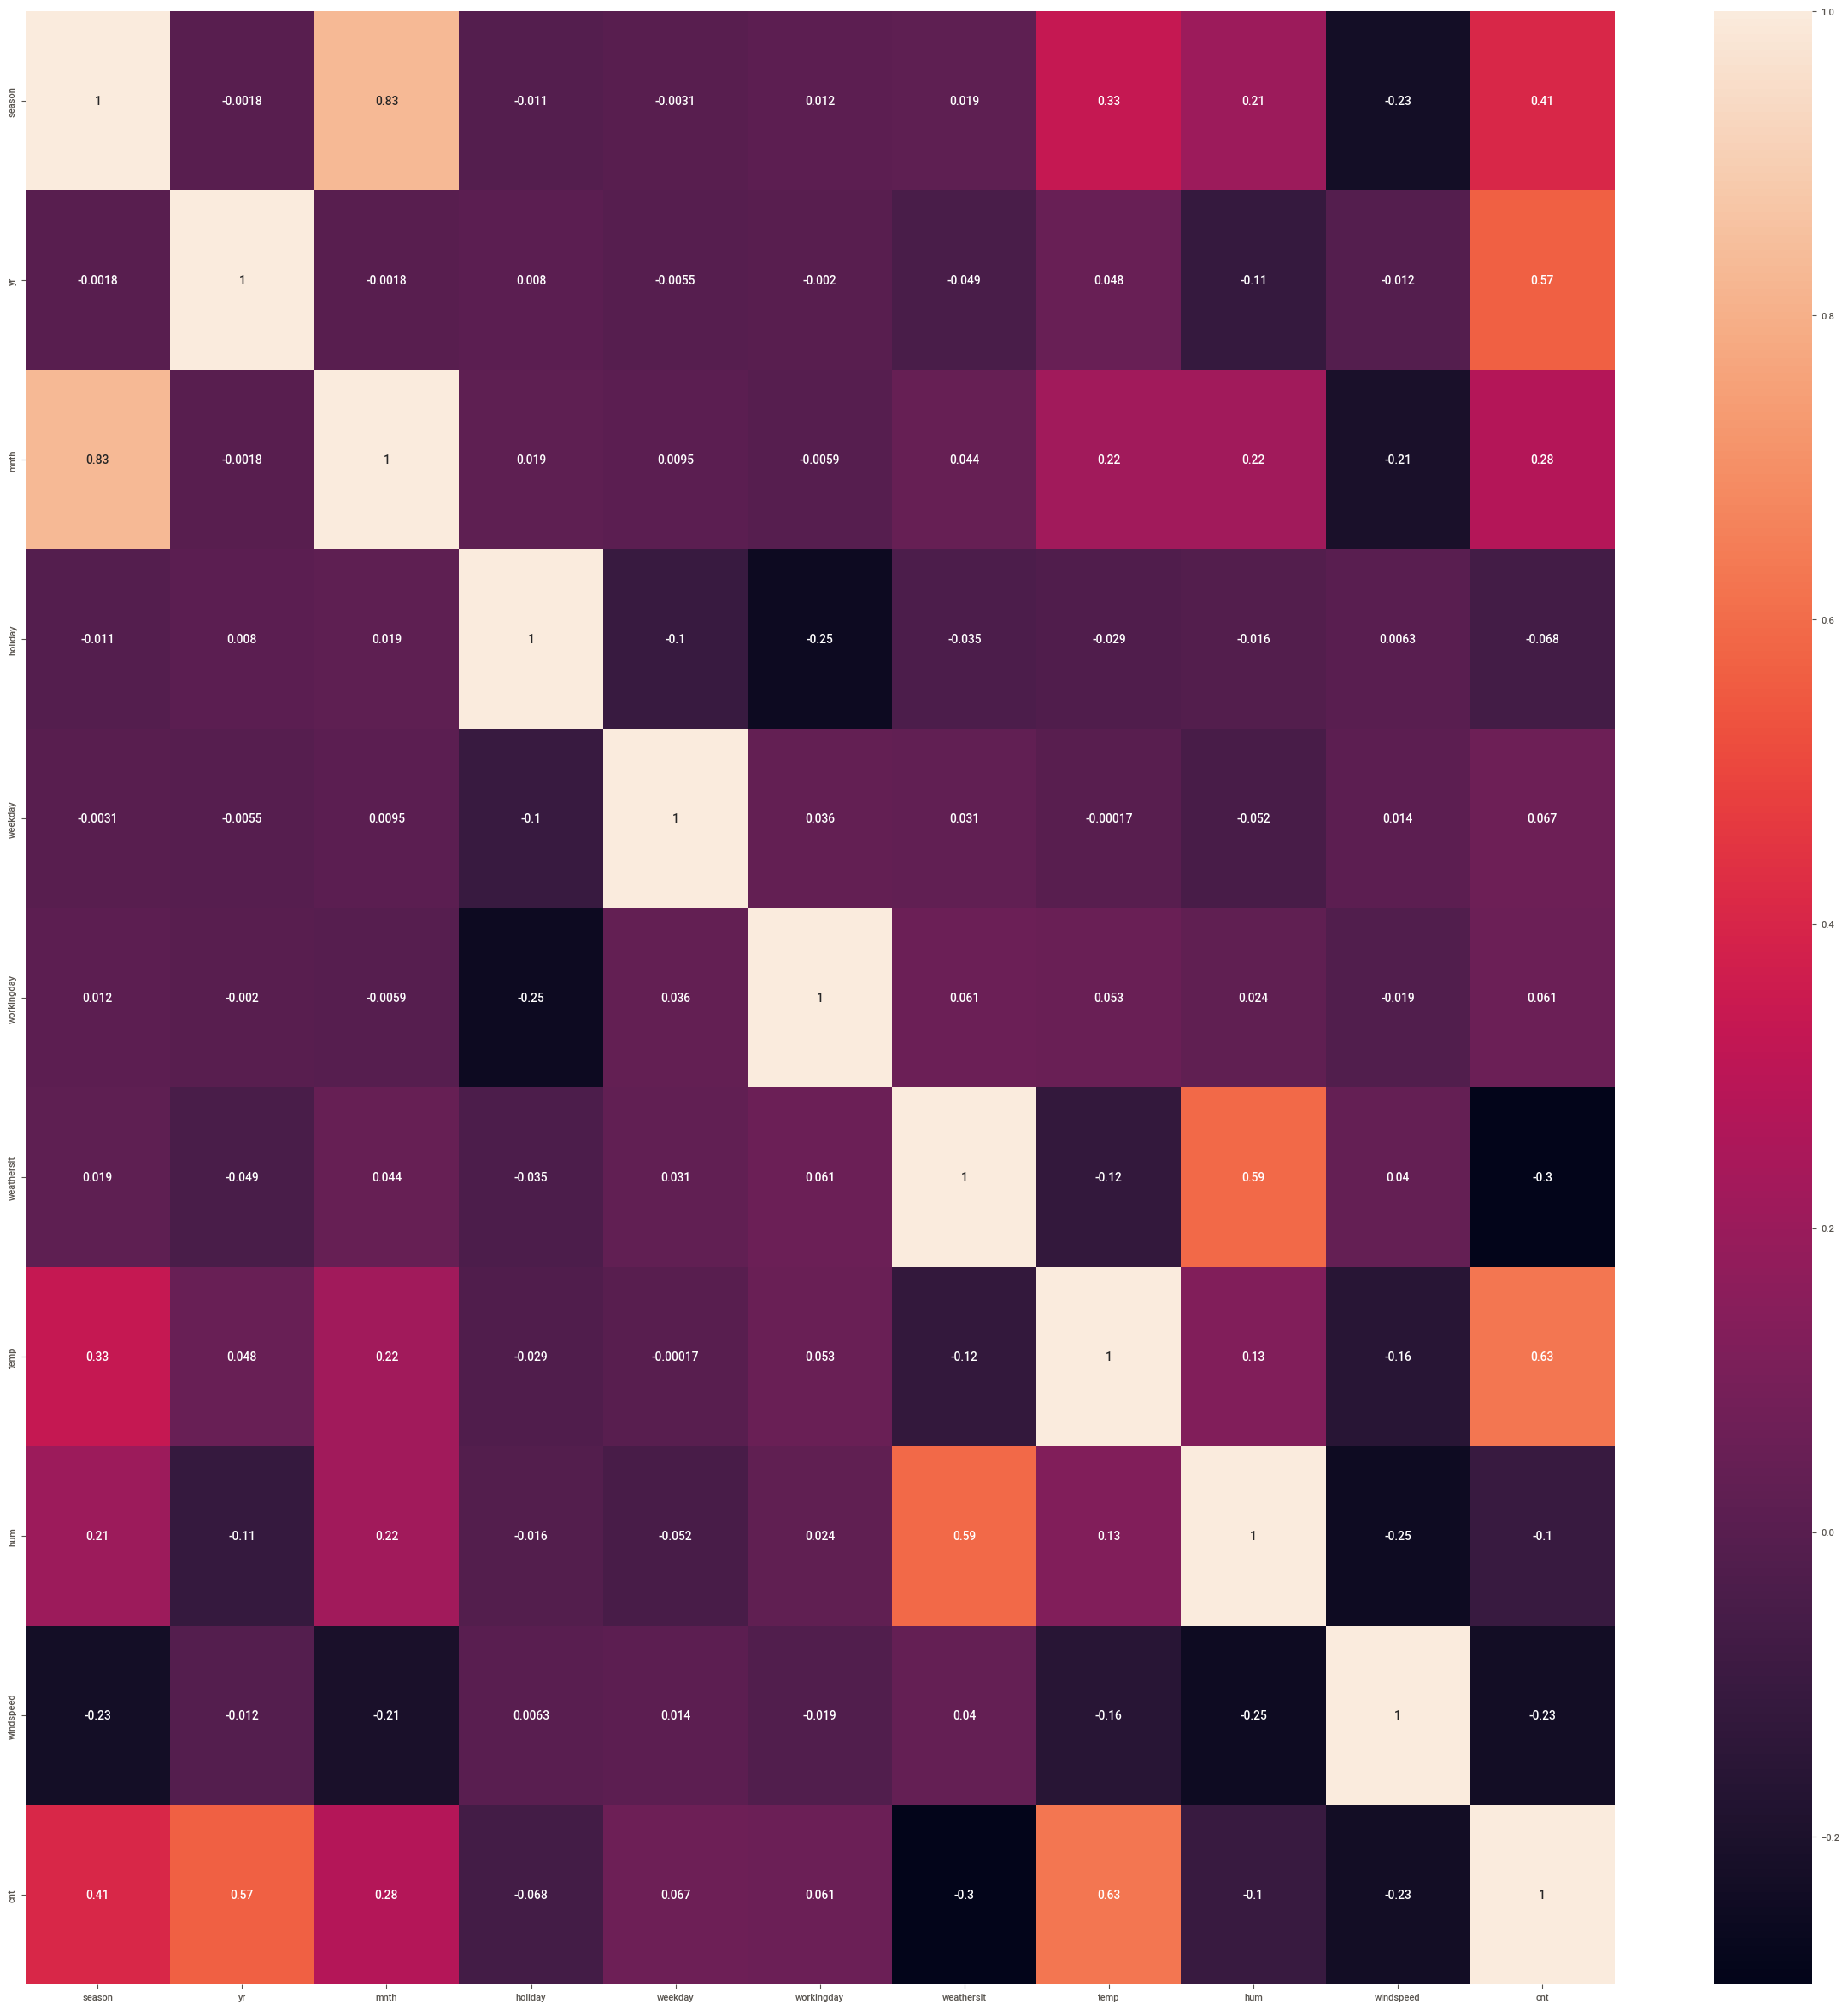

In [ ]:
plt.figure(figsize = (30,30))
sns.heatmap(data.corr(),annot = True)

#**Model Creation**

**Data split( x and y)**

In [ ]:
x = data.drop(['cnt'],axis = 1)
y = data['cnt']

In [ ]:
x

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed
0,1,0,1,0,6,0,2,0.344167,0.805833,0.160446
1,1,0,1,0,0,0,2,0.363478,0.696087,0.248539
2,1,0,1,0,1,1,1,0.196364,0.437273,0.248309
3,1,0,1,0,2,1,1,0.200000,0.590435,0.160296
4,1,0,1,0,3,1,1,0.226957,0.436957,0.186900
...,...,...,...,...,...,...,...,...,...,...
726,1,1,12,0,4,1,2,0.254167,0.652917,0.350133
727,1,1,12,0,5,1,2,0.253333,0.590000,0.155471
728,1,1,12,0,6,0,2,0.253333,0.752917,0.124383
729,1,1,12,0,0,0,1,0.255833,0.483333,0.350754


In [ ]:
y

,cnt
0,985
1,801
2,1349
3,1562
4,1600
...,...
726,2114
727,3095
728,1341
729,1796


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y)

#**Linear Regression**

Base line model

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
lr = model.score(x_train,y_train)
print('Accuracy of the model is :',lr*100,'%')

Accuracy of the model is : 78.82108452983917 %


In [ ]:
y_predict = model.predict(x_test)

In [ ]:
from sklearn import preprocessing,metrics,linear_model
from sklearn.model_selection import cross_val_score,cross_val_predict,train_test_split

In [ ]:
r2_score = cross_val_score(model,x,y,cv = 3)
print('r2 score =',np.average(r2_score))

r2 score = 0.6041449895043866


In [ ]:
predict = cross_val_predict(model,x,y,cv = 3)
print('predict =',(predict))

predict = [1669.41318871 1215.88542658 1631.55863255 1733.4474762  2166.18448363
 2274.69282285 1430.87886435  780.04736229  687.65058335 1362.36123382
  833.76172343 1185.15696885 1466.80974915 1950.82576561 1587.87300508
 1687.6219028   -92.70753783  715.7778348  1260.665246   1571.82562013
 1480.69964009 1373.58628146  802.73298819 1239.32804162 1252.29990396
 -328.246952   1837.19298645 1080.99661219 1801.67842538 1527.49378105
  765.86725098  889.09519191  799.44533971 1690.40385161 1452.34220171
  761.61223911 1960.15127613 2126.71165316 1278.9117328   815.83791176
 1618.56424258 2192.35187456 1928.90004047 1965.27529432 2446.5689457
 2169.76869219 2481.86064461 3168.71157343 3619.40380857 2646.89801663
 1991.15047179  133.14389751 1504.89873732 2416.41404129 1273.30173762
 1425.84774246 2342.67047336 2145.76878155 1232.20410084 1972.62122023
 2319.19757479 2100.27812833 1425.9821042  1571.89674781  463.71812778
 1439.97949879 2631.37823566 1110.63111968 2343.17234409 1581.446876

**R-squared and mean squared error score**

In [ ]:
r2_scores = cross_val_score(model,x,y,cv = 3)
print('r2 score =',np.average(r2_scores))

r2 score = 0.6041449895043866


In [ ]:
adjusted_r2_score = 1-(1-r2_score)*(len(y)-1)/(len(y)-x.shape[1]-1)
print('adjusted r2 score =',np.average(adjusted_r2_score))


adjusted r2 score = 0.598647003247503


In [ ]:
from sklearn.metrics import mean_absolute_error
import math
mse = np.square(np.subtract(y_test,y_predict)).mean()
rmse = math.sqrt(mse)
mae = mean_absolute_error(y_test,y_predict)
print('mse =',mse)
print('rmse =',rmse)
print('mae = ',mae)

mse = 667234.9636609647
rmse = 816.8445162091527
mae =  635.0302991219821


The RMSE value is 816.844,indicating a large prediction error.the MAE value is 635.03,showing an average prediction errors of approximately 635.030. units

#**Random forest regressior**

In [ ]:
from sklearn.ensemble import RandomForestRegressor
model_rt = RandomForestRegressor()
model_rt.fit(x_train,y_train)

RandomForestRegressor()

In [ ]:
rf_score_rt = model_rt.score(x_train,y_train)
print('Accuracy of the model is :',rf_score*100,'%')

Accuracy of the model is : 98.13758206708978 %


In [ ]:
predict = cross_val_predict(model_rt,x_train,y_train,cv = 3)
print('predict =',(predict))

predict = [5373.17 7540.1  5699.93 6422.77 7606.1  4326.08 2498.46 4633.15 6206.47
 1113.31 5520.2  5219.95 4599.26 5049.35 2690.82 3340.02 5265.35 6217.25
 6606.2  3919.18 1290.1  6301.29 2446.52 6799.84 3707.98 4984.42 2144.86
 4418.63 4764.74 5193.51 6562.8  4906.37 6389.11 6066.72 1985.16 7218.98
 1466.38 4831.72 4271.01 4668.24 7428.1  3850.69 7201.49 4491.6  6631.67
 2559.67 7502.86 5475.12 1940.15 3855.43 4215.79 3295.95 3958.08 3402.6
 6629.9  5239.22 7625.41 1465.22 4589.14 5105.38 6432.54 3270.69 4395.46
 4196.53 6330.03 1971.27 3097.36 4058.7  7379.91 5006.02 1623.48 6694.12
 1332.89 4140.33 1224.97 4203.18 2774.03 5370.35 1104.98 6164.39 3425.33
 2193.23 6971.5  5852.51 6181.91 3013.52 7399.75 4376.1  6365.06 4855.45
 5032.86 3650.79 7452.45 1137.27 7350.48 7682.18 1781.1  4326.06 5893.81
 6129.47 4880.44 1053.32 2378.97 5541.68 1815.1  4656.26 4631.73 6521.52
 1615.75 4246.38 4060.49 4589.84 4971.46 1510.25 6270.34 1917.75 3551.17
 4599.39 4476.45 3096.95 4454.68 4340.75 4

In [ ]:
r2_score_rt = cross_val_score(model_rt,x_train,y_train,cv = 3)
print('r2 score =',np.average(r2_score_rt))

r2 score = 0.8664554764891289


In [ ]:
rf_pred_rt = model_rt.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
import math
mse_rt = np.square(np.subtract(y_test,rf_pred_rt)).mean()
rmse_rt = math.sqrt( metrics.mean_squared_error(y_test,rf_pred_rt))
mae_rt = mean_absolute_error(y_test,rf_pred_rt)
r2_score_rt = r2_score(y_test,rf_pred_rt)
print('r2 score =',r2_score_rt)
print('mse =',mse_rt)
print('rmse =',rmse_rt)
print('mae = ',mae_rt)

r2 score = 0.8965848227271901
mse = 395369.000937705
rmse = 628.7837473549273
mae =  428.35355191256826


ROOT MEAN SQUARE EROOR = 628.78

MEAN ABSOLUTE ERROR = 428.35

#**FINAL MODEL**


**Observation and conclusion**

when we compare random forest with linear regression the forest shows less mean root error and mean absolute error.also the accuaracy according to r_2 score is also high for random forest.so finally random forest model is the best for predicting the bike rental count on daily basis

#**CONCLUSION**



This project analysed the bike sharing data set to understand the factors that influence daily bike rental demand and to develop a ML model for predicting the total number of rental bikes. the analysis considered different seasons,weather,environmental,and calendar- related variables and examined their relationship with bike rental demand.

Two regression alogorithims were implemented and evaluated, linear regression and random forest regression.the models were compared using evaluation metrics such as R2,mean absolute error,and root mean square error.

Random forest was able produce a satisfactory result because of its ability to capture non- linear relationships between weather,seasonal,and other influenceing factors made it more sutiable for this data ser than the simpler regression models.

Overall,the project sucessfully demonstrated the complete data science workflow,from data exploration and preprocessing to model development evaluation and selection of a suitable prediction model.